### FASE 2. Limpieza y transformación de datos

**Proyecto:** Análisis Exploratorio de Datos — Ingresos totales por ventas a clientes de un comercio.

**Objetivo de esta fase:**
Corregir errores, tratar datos incompletos y dejar el dataset preparado para el análisis exploratorio (Fase 3).

**Punto de partida:** `01_datos_integrados.csv` (52.000 filas × 37 columnas), resultado de la Fase 1.

**Flujo de limpieza que seguiremos:**
1. Importación de Librerias y Exploración inicial 
2. Corregir tipos de datos.
3. Tratar valores nulos.
4. Eliminar duplicados.
5. Limpiar datos inconsistentes.
6. Eliminar variables irrelevantes.
7. Detectar y tratar outliers.
8. Validación final y guardado del dataset limpio.

#### 1️⃣ Importacion de librerias y Exploración inicial

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns',None)

df = pd.read_csv(r"../data/processed/01_datos_integrados.csv")
df.head(3).T


,0,1,2
order_id,1,2,3
id_,7ec28fa9-cad8-4f9a-a5b4-04a3f722c107,0f14d6ee-e853-448f-a20f-d6c933956321,5db0a392-f9b6-48c4-a1b0-bdd040ab4917
product_id,P0086,P0086,P0001
fecha_pedido,3-septiembre-2022,18-noviembre-2022,14-enero-2022
cantidad,4,1,1
precio_unitario,"27,29","68,24","25,84"
descuento,0.1,0.05,0.1
importe_total,"98,23","64,83","23,26"
metodo_pago,PAYPAL,PayPal,Tarjeta de credito
envio_gratis,0,0,0


Tamaño del DataFrame

In [2]:
print(f"El archivo 01_carga_integracion tiene {df.shape[0]} filas y {df.shape[1]} columnas")

El archivo 01_carga_integracion tiene 52000 filas y 37 columnas


Informacion General

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52000 entries, 0 to 51999
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  52000 non-null  int64  
 1   id_                       52000 non-null  str    
 2   product_id                52000 non-null  str    
 3   fecha_pedido              52000 non-null  str    
 4   cantidad                  52000 non-null  int64  
 5   precio_unitario           52000 non-null  str    
 6   descuento                 52000 non-null  float64
 7   importe_total             52000 non-null  str    
 8   metodo_pago               51220 non-null  str    
 9   envio_gratis              52000 non-null  int64  
 10  calificacion              44227 non-null  float64
 11  devuelto                  52000 non-null  str    
 12  canal                     52000 non-null  str    
 13  hoja_origen               52000 non-null  int64  
 14  categoria_product

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,52000.0,NaN,NaN,NaN,26000.5,15011.251336,1.0,13000.75,26000.5,39000.25,52000.0
id_,52000,7987,f9d54acf-ff02-4eda-a470-4e10a762f16a,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,52000,90,P0003,678,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_pedido,52000,1457,2-junio-2022,57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cantidad,52000.0,NaN,NaN,NaN,2.047192,1.201054,1.0,1.0,2.0,3.0,5.0
precio_unitario,52000,12918,"32,51",18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
descuento,52000.0,NaN,NaN,NaN,0.070436,0.076881,0.0,0.0,0.05,0.1,0.3
importe_total,52000,21552,"24,24",15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
metodo_pago,51220,12,tarjeta de debito,6464,NaN,NaN,NaN,NaN,NaN,NaN,NaN
envio_gratis,52000.0,NaN,NaN,NaN,0.301288,0.458822,0.0,0.0,0.0,1.0,1.0


In [5]:
df.describe(include='string').T

,count,unique,top,freq
id_,52000,7987,f9d54acf-ff02-4eda-a470-4e10a762f16a,20
product_id,52000,90,P0003,678
fecha_pedido,52000,1457,2-junio-2022,57
precio_unitario,52000,12918,"32,51",18
importe_total,52000,21552,"24,24",15
metodo_pago,51220,12,tarjeta de debito,6464
devuelto,52000,4,NO,24633
canal,52000,4,Web,20887
categoria_producto,52000,5,Electronica,10596
nombre_producto,52000,90,Auriculares Nova Max,678


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,52000.0,26000.500000,15011.251336,1.000,13000.750,26000.500,39000.250,52000.000
cantidad,52000.0,2.047192,1.201054,1.000,1.000,2.000,3.000,5.000
descuento,52000.0,0.070436,0.076881,0.000,0.000,0.050,0.100,0.300
envio_gratis,52000.0,0.301288,0.458822,0.000,0.000,0.000,1.000,1.000
calificacion,44227.0,4.052502,1.048372,1.000,4.000,4.000,5.000,5.000
hoja_origen,52000.0,2023.500000,1.118045,2022.000,2022.750,2023.500,2024.250,2025.000
peso_kg,52000.0,6.216765,3.513158,0.300,2.950,6.890,9.280,11.980
stock_disponible,52000.0,250.003231,134.013918,5.000,148.000,263.000,368.000,488.000
rating_promedio_producto,50867.0,3.876116,0.682173,2.630,3.330,3.860,4.450,5.000
edad,48961.0,40.153551,12.517461,18.000,31.000,40.000,48.000,85.000


Valores unicos

In [7]:
df.nunique()

order_id                    52000
id_                          7987
product_id                     90
fecha_pedido                 1457
cantidad                        5
precio_unitario             12918
descuento                       6
importe_total               21552
metodo_pago                    12
envio_gratis                    2
calificacion                    5
devuelto                        4
canal                           4
hoja_origen                     4
categoria_producto              5
nombre_producto                90
marca                           8
costo_unitario                 88
precio_lista                   90
peso_kg                        89
proveedor                       4
stock_disponible               84
fecha_lanzamiento              88
rating_promedio_producto       75
edad                           67
estado_civil                    9
nivel_educativo                 5
ingresos_anuales             7414
tiene_hijos                     2
adolescentes_e

In [8]:
# Analizamor valores unicos y tipo de valor
valores = pd.DataFrame({
    'nunique': df.nunique(),
    'dtype': df.dtypes,
})

valores

,nunique,dtype
order_id,52000,int64
id_,7987,str
product_id,90,str
fecha_pedido,1457,str
cantidad,5,int64
precio_unitario,12918,str
descuento,6,float64
importe_total,21552,str
metodo_pago,12,str
envio_gratis,2,int64


#### 2️⃣ Corregir tipos de datos

Corregimos los tipos **antes** de tratar los nulos, ya que muchas columnas numéricas están almacenadas como texto y esto afectaría al cálculo de medias/medianas para la imputación. 

Nota: esta información está recogida en la Fase 1 Observaciones Inciales que unificaremos aqui. 


Verificador de procesos

In [9]:
datos = pd.DataFrame({
    'nunique': df.nunique(),
    'dtype': df.dtypes,
    'ejemplos': df.apply(lambda x: "   ".join(map(str, x.sample(2))))
})

datos

,nunique,dtype,ejemplos
order_id,52000,int64,25150 15785
id_,7987,str,012703e4-488c-46ab-a369-aa50324576c4 11736a0...
product_id,90,str,P0003 P0029
fecha_pedido,1457,str,20-junio-2024 21-noviembre-2023
cantidad,5,int64,2 4
precio_unitario,12918,str,"115,19 25,13"
descuento,6,float64,0.0 0.0
importe_total,21552,str,"203,91 12,81"
metodo_pago,12,str,paypal Tarjeta de credito
envio_gratis,2,int64,0 1


2.1. Columnas `fecha_registro, fecha_lanzamiento ,fecha_pedido` (texto con mes en español → datetime)

In [10]:
df[['fecha_registro','fecha_lanzamiento','fecha_pedido']].dtypes

fecha_registro       str
fecha_lanzamiento    str
fecha_pedido         str
dtype: object

In [11]:
df[['fecha_registro','fecha_lanzamiento','fecha_pedido']].sample(3)

,fecha_registro,fecha_lanzamiento,fecha_pedido
10053,24-marzo-2020,24-diciembre-2023,25-enero-2022
28206,16-noviembre-2020,8-marzo-2019,5-junio-2024
4459,7-diciembre-2018,23-septiembre-2022,18-junio-2022


Comvertimos columnas a datetime 

In [12]:
meses = {
    "enero": "01",
    "febrero": "02",
    "marzo": "03",
    "abril": "04",
    "mayo": "05",
    "junio": "06",
    "julio": "07",
    "agosto": "08",
    "septiembre": "09",
    "octubre": "10",
    "noviembre": "11",
    "diciembre": "12",
}

# Reemplazar los nombres de los meses
fechas =['fecha_registro','fecha_lanzamiento','fecha_pedido']

df[fechas] = df[fechas].replace(meses, regex=True)


# Convertir a datetime
for col in fechas: 
    df[col] = pd.to_datetime(df[col], format="%d-%m-%Y", errors="coerce")

df[fechas].sample(3)

,fecha_registro,fecha_lanzamiento,fecha_pedido
335,2021-03-07,2021-09-23,2022-09-06
30495,2018-07-30,2019-05-22,2024-04-16
4897,2022-03-26,2023-04-11,2022-01-02


In [13]:
df[fechas].dtypes

fecha_registro       datetime64[us]
fecha_lanzamiento    datetime64[us]
fecha_pedido         datetime64[us]
dtype: object

**Observaciones**
- Las columnas `fecha_registro, fecha_lanzamiento , fecha_pedido` han sido primero modificado el texto mes a numero y despues convertidas a datetime.

2.2. Columnas económicas de string → float, y reemplazar "," por "."

In [14]:
df[["costo_unitario", "precio_lista", "precio_unitario", "importe_total"]].dtypes

costo_unitario     str
precio_lista       str
precio_unitario    str
importe_total      str
dtype: object

In [15]:
numeros = ["costo_unitario", "precio_lista", "precio_unitario", "importe_total"]

for col in numeros:
    df[col] = df[col].astype(str).str.replace(",", ".", regex=False)
    df[col] = pd.to_numeric(df[col], errors="coerce").astype(float)

df[numeros].dtypes

costo_unitario     float64
precio_lista       float64
precio_unitario    float64
importe_total      float64
dtype: object

In [16]:
df[["costo_unitario", "precio_lista", "precio_unitario", "importe_total"]].nunique()

costo_unitario        88
precio_lista          90
precio_unitario    12918
importe_total      21552
dtype: int64

**Observaciones**
- Las columnas `"costo_unitario", "precio_lista", "precio_unitario", "importe_total"` se ha reemplazar la "," por el "." y se han convertido los valores a float.

2.3. Columnas con mayusculas y espacios a minusculas (unificar todos los datos)

In [17]:
# Analizamos columnas String, menos id,producto_in y nombre_producto(Analizarmos por separado)
val_unicos = pd.DataFrame({
    col: pd.Series(df[col].unique())
    for col in df.select_dtypes(include=["object", "string"]).columns
    if col not in ["id_","product_id","nombre_producto"]
})

val_unicos

,metodo_pago,devuelto,canal,categoria_producto,marca,proveedor,estado_civil,nivel_educativo,ciudad,region,segmento_cliente
0,PAYPAL,no,App movil,Libros,Vantia,Norte Logistica,Soltero,grado universitario,Valencia,Este,Nuevo
1,PayPal,SI,Tienda fisica,Electronica,Urbanix,Global Supply SL,CASADO,bachillerato,Bilbao,Norte,Recurrente
2,Tarjeta de credito,NO,Marketplace,Deporte,Kore,Distribuidora Iberia,casado,basico,Malaga,Sur,Corporativo
3,CONTRAREEMBOLSO,si,Web,Hogar,Nova,Comercial Atlas,SOLTERO,master,Vigo,Centro,VIP
4,Tarjeta de debito,NaN,NaN,Ropa,Norte&Co,NaN,Casado,doctorado,Sevilla,NaN,NaN
5,tarjeta de credito,NaN,NaN,NaN,Prisma,NaN,NaN,NaN,Madrid,NaN,NaN
6,tarjeta de debito,NaN,NaN,NaN,Zentra,NaN,soltero,NaN,Barcelona,NaN,NaN
7,TARJETA DE CREDITO,NaN,NaN,NaN,Lumen,NaN,divorciado,NaN,Murcia,NaN,NaN
8,contrareembolso,NaN,NaN,NaN,NaN,NaN,Divorciado,NaN,Granada,NaN,NaN
9,transferencia,NaN,NaN,NaN,NaN,NaN,DIVORCIADO,NaN,Zaragoza,NaN,NaN


In [18]:
cols = [
    "metodo_pago", "devuelto", "canal", "categoria_producto",
    "marca", "proveedor", "estado_civil",
    "nivel_educativo", "ciudad", "region", "segmento_cliente"
]

df[cols] = df[cols].apply(lambda x: x.str.strip().str.lower())

Realizamos una verificacion de que se han realizado los cambios

In [19]:
val_unicos_mod = pd.DataFrame({
    col: pd.Series(df[col].unique())
    for col in df.select_dtypes(include=["object", "string"]).columns
    if col not in ["id_","product_id","nombre_producto"]
})

val_unicos_mod

,metodo_pago,devuelto,canal,categoria_producto,marca,proveedor,estado_civil,nivel_educativo,ciudad,region,segmento_cliente
0,paypal,no,app movil,libros,vantia,norte logistica,soltero,grado universitario,valencia,este,nuevo
1,tarjeta de credito,si,tienda fisica,electronica,urbanix,global supply sl,casado,bachillerato,bilbao,norte,recurrente
2,contrareembolso,NaN,marketplace,deporte,kore,distribuidora iberia,NaN,basico,malaga,sur,corporativo
3,tarjeta de debito,NaN,web,hogar,nova,comercial atlas,divorciado,master,vigo,centro,vip
4,transferencia,NaN,NaN,ropa,norte&co,NaN,NaN,doctorado,sevilla,NaN,NaN
5,NaN,NaN,NaN,NaN,prisma,NaN,NaN,NaN,madrid,NaN,NaN
6,NaN,NaN,NaN,NaN,zentra,NaN,NaN,NaN,barcelona,NaN,NaN
7,NaN,NaN,NaN,NaN,lumen,NaN,NaN,NaN,murcia,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,granada,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,zaragoza,NaN,NaN


**Observaciones**
- Las columnas `"metodo_pago", "devuelto", "canal", "categoria_producto",
    "marca", "proveedor", "estado_civil",
    "nivel_educativo", "ciudad", "region", "segmento_cliente"` se han eliminado los espadios y convertidas en misnusculas

2.4. Analizamos columna `"nombre_producto"` para revisar si hay valores incorrectos

In [20]:
# Comprobamos que no existen valores incorrectos
originales = df["nombre_producto"].dropna().nunique()
normalizados = df["nombre_producto"].dropna().str.strip().str.lower().nunique()

print(f"Únicos originales: {originales}")
print(f"Únicos tras normalizar (minúsculas + sin espacios extra): {normalizados}")

Únicos originales: 90
Únicos tras normalizar (minúsculas + sin espacios extra): 90


In [21]:
# Verificamos de forma visual
df["nombre_producto"].dropna().sort_values().unique()

<ArrowStringArray>
[  'Aspiradora Norte&Co Max',   'Aspiradora Vantia Basic',
     'Aspiradora Vantia Pro',      'Auriculares Nova Max',
 'Auriculares Urbanix Basic',   'Auriculares Urbanix Pro',
            'Balon Kore Max',        'Balon Vantia Basic',
          'Balon Zentra Pro',      'Bicicleta Kore Basic',
        'Bicicleta Kore Pro',      'Bicicleta Zentra Max',
        'Biografia Kore Pro',        'Biografia Nova Max',
    'Biografia Zentra Basic',   'Cafetera Norte&Co Basic',
         'Cafetera Nova Pro',       'Cafetera Zentra Max',
           'Camara Kore Max',          'Camara Lumen Pro',
     'Camara Norte&Co Basic',     'Camiseta Prisma Basic',
       'Camiseta Vantia Max',       'Camiseta Vantia Pro',
           'Casco Lumen Pro',        'Casco Norte&Co Max',
        'Casco Vantia Basic',       'Chaqueta Kore Basic',
     'Chaqueta Norte&Co Max',       'Chaqueta Zentra Pro',
            'Comic Kore Max',        'Comic Norte&Co Pro',
        'Comic Prisma Basic',       '

**Observaciones**
- La columna `"nombre_producto"` no existen datos que corregir o modificar, no se realiza ninguna modificación.

2.5. Columnas binarias `envio_gratis`, `tiene_hijos`, `adolescentes_en_casa` → texto legible

Estas columnas son categóricas (Sí/No) aunque estén almacenadas como 0.0/1.0. Las convertimos a texto (`"si"` / `"no"`) para que sean coherentes  y más claras en los gráficos de la Fase 3. Los nulos se mantienen de momento (se tratarán en el siguiente paso).

In [22]:
df[["envio_gratis", "tiene_hijos", "adolescentes_en_casa"]].nunique()

envio_gratis            2
tiene_hijos             2
adolescentes_en_casa    2
dtype: int64

In [23]:
df[["envio_gratis", "tiene_hijos", "adolescentes_en_casa"]].apply(lambda c: c.value_counts(dropna=False))

,envio_gratis,tiene_hijos,adolescentes_en_casa
0.0,36333.0,28163,36083.0
1.0,15667.0,22799,15917.0
NaN,NaN,1038,NaN


In [24]:
for col in ["envio_gratis", "tiene_hijos", "adolescentes_en_casa"]:
    df[col] = df[col].replace({1.0: "si", 0.0: "no"}).astype("str")

In [25]:
df[["envio_gratis", "tiene_hijos", "adolescentes_en_casa"]].dtypes

envio_gratis            str
tiene_hijos             str
adolescentes_en_casa    str
dtype: object

In [26]:
df[["envio_gratis", "tiene_hijos", "adolescentes_en_casa"]].apply(lambda c: c.value_counts(dropna=False))

,envio_gratis,tiene_hijos,adolescentes_en_casa
no,36333.0,28163,36083.0
si,15667.0,22799,15917.0
NaN,NaN,1038,NaN


**Observaciones**
- Las columnas binarias `envio_gratis`, `tiene_hijos`, `adolescentes_en_casa` están almacenadas como 0.0/1.0 (`float`). Las convertimos a texto (`"si"` / `"no"`). 

Los nulos se mantienen de momento (se tratarán en el siguiente paso). Aunque estas columnas son categóricas (Sí/No), se ha decido cambiarlas a `string` para que sean coherentes  y más claras en los gráficos de la Fase 3

2.6. Columna `hoja_origen` renombramos como `año_ventas`

In [27]:
df["hoja_origen"].value_counts()

hoja_origen
2022    13000
2023    13000
2024    13000
2025    13000
Name: count, dtype: int64

In [28]:
df["hoja_origen"] = df["hoja_origen"].astype(str)
df = df.rename(columns={"hoja_origen": "año_ventas"})
df["año_ventas"].value_counts()

año_ventas
2022    13000
2023    13000
2024    13000
2025    13000
Name: count, dtype: int64

**Observaciones**
- La columna `"hoja_origen"` se renombra como columnas `año_ventas`y se convierte a `string`.

2.7. Columna `id_` renombramos como `id_clientes`

In [29]:
df['id_'].value_counts()

id_
f9d54acf-ff02-4eda-a470-4e10a762f16a    20
cd1c7936-b0af-45b4-9903-37685d990d8f    18
47087e3e-a67b-4354-9bd8-1ecb5b2a653c    18
dfa29b4e-02c3-4bc8-b327-333bbab375f9    17
4bcbfc08-e5f3-49b1-99ab-fb6b41e246f7    17
                                        ..
145819ca-c84f-460b-9cab-be36305569af     1
8aa70d5e-5ae9-473e-82d6-a06f76ef9b85     1
4389835b-129c-4131-9a4e-1ebddb4d3b1e     1
62e8c2b6-f5ea-433c-bcbe-1eb76f0bb7a7     1
f70a8df3-6df3-4857-9334-68ea80810a93     1
Name: count, Length: 7987, dtype: int64

In [30]:
df = df.rename(columns={"id_":"id_cliente"})
df.columns

Index(['order_id', 'id_cliente', 'product_id', 'fecha_pedido', 'cantidad',
       'precio_unitario', 'descuento', 'importe_total', 'metodo_pago',
       'envio_gratis', 'calificacion', 'devuelto', 'canal', 'año_ventas',
       'categoria_producto', 'nombre_producto', 'marca', 'costo_unitario',
       'precio_lista', 'peso_kg', 'proveedor', 'stock_disponible',
       'fecha_lanzamiento', 'rating_promedio_producto', 'edad', 'estado_civil',
       'nivel_educativo', 'ingresos_anuales', 'tiene_hijos',
       'adolescentes_en_casa', 'fecha_registro', 'ciudad', 'region',
       'latitude', 'longitude', 'segmento_cliente', 'visitas_web_mes'],
      dtype='str')

**Observaciones**
- La columna `"id_"` se renombra como columnas `id_cliente`y se observa que hay duplicados, que estudiaremos mas adelante si hay que eliminar.

**Realizamos una Verificacion de los cambios en df antes de pasar a Tratar valores nulos.**

In [31]:
datos = pd.DataFrame({
    'nunique': df.nunique(),
    'dtype': df.dtypes,
    'ejemplos': df.apply(lambda x: "   ".join(map(str, x.sample(2))))
})

datos

,nunique,dtype,ejemplos
order_id,52000,int64,48679 43210
id_cliente,7987,str,bff85ac3-e051-4a6a-b019-3251f3e24f45 685d88c...
product_id,90,str,P0011 P0046
fecha_pedido,1457,datetime64[us],2024-05-15 00:00:00 2023-12-17 00:00:00
cantidad,5,int64,1 1
precio_unitario,12918,float64,46.73 49.22
descuento,6,float64,0.15 0.05
importe_total,21552,float64,40.32 161.41
metodo_pago,5,str,tarjeta de debito tarjeta de debito
envio_gratis,2,str,si no


#### 3️⃣ Tratar valores nulos

In [32]:
def resumen_nulos(df):
    """
    Devuelve un resumen de las columnas con valores nulos:
    cantidad, porcentaje y tipo de dato.
    """
    nulos = df.isna().sum()
    nulos = nulos[nulos > 0]

    nulos_pct = (df.isna().mean() * 100).round(2)
    nulos_pct = nulos_pct[nulos_pct.index.isin(nulos.index)]

    resumen = pd.DataFrame({
        'nulos': nulos,
        '% nulos': nulos_pct,
        'dtype': df.dtypes[nulos.index]
    }).sort_values('% nulos', ascending=False)

    return resumen

In [33]:
resumen_nulos(df)

,nulos,% nulos,dtype
calificacion,7773,14.95,float64
edad,3039,5.84,float64
nivel_educativo,2063,3.97,str
rating_promedio_producto,1133,2.18,float64
tiene_hijos,1038,2.00,str
metodo_pago,780,1.50,str
marca,567,1.09,str
estado_civil,524,1.01,str
fecha_registro,253,0.49,datetime64[us]


3.1. Columnas numéricas ["calificacion", "rating_promedio_producto", "edad"]

In [34]:
col_numericas = ["calificacion", "rating_promedio_producto", "edad"]

In [35]:
col_num_desc = df[col_numericas]
col_num_desc.describe()

,calificacion,rating_promedio_producto,edad
count,44227.000000,50867.000000,48961.000000
mean,4.052502,3.876116,40.153551
std,1.048372,0.682173,12.517461
min,1.000000,2.630000,18.000000
25%,4.000000,3.330000,31.000000
50%,4.000000,3.860000,40.000000
75%,5.000000,4.450000,48.000000
max,5.000000,5.000000,85.000000


Se optó por imputar los valores nulos con la **mediana**, en lugar de la media, por los siguientes motivos:

- Al comparar media y mediana en las tres columnas, la diferencia entre ambas es mínima 
  (0.02–0.15 puntos), lo que indica distribuciones aproximadamente simétricas y sin 
  outliers relevantes que distorsionen el resultado.
- Aun así, se prioriza la mediana como criterio general por ser una medida más robusta 
  ante valores extremos, especialmente en `edad`, donde el valor máximo es (85) y 
  como `calificacion` (1-5) y `rating_promedio_producto` (~2.6-5), 
  la mediana más apropiada.


In [36]:
col_numericas

['calificacion', 'rating_promedio_producto', 'edad']

In [37]:
# Convertimos los nulos de col_numericas a la mediana
for col in col_numericas:
    df[col]=df[col].fillna(df[col].median())

In [38]:
# Realizamos comprobación
df[col_numericas].isna().sum()

calificacion                0
rating_promedio_producto    0
edad                        0
dtype: int64

3.2. Columnas categóricas 

In [39]:
resumen_nulos(df)

,nulos,% nulos,dtype
nivel_educativo,2063,3.97,str
tiene_hijos,1038,2.00,str
metodo_pago,780,1.50,str
marca,567,1.09,str
estado_civil,524,1.01,str
fecha_registro,253,0.49,datetime64[us]


In [40]:
cols_categoricas = ["metodo_pago","marca","estado_civil","nivel_educativo","tiene_hijos"]

In [41]:
df[cols_categoricas].describe()

,metodo_pago,marca,estado_civil,nivel_educativo,tiene_hijos
count,51220,51433,51476,49937,50962
unique,5,8,3,5,2
top,tarjeta de credito,vantia,casado,grado universitario,no
freq,17964,10898,25811,17482,28163


Columnas `"metodo_pago", "marca", "estado_civil", "nivel_educativo"`<br>
Para las 4 con más categorías: preservar la información del nulo

In [42]:
for col in ["metodo_pago", "marca", "estado_civil", "nivel_educativo"]:
    df[col] = df[col].fillna("desconocido")


Columna tiene hijos `"tiene_hijos"`

In [43]:
df["tiene_hijos"].mode()

0    no
Name: tiene_hijos, dtype: str

In [44]:
# tiene_hijos: binaria, aceptable usar moda si prefieres mantenerla como si/no
df["tiene_hijos"] = df["tiene_hijos"].fillna(df["tiene_hijos"].mode()[0])

In [45]:
# Realizamos comprobación
df[cols_categoricas].isna().sum()

metodo_pago        0
marca              0
estado_civil       0
nivel_educativo    0
tiene_hijos        0
dtype: int64

3.3. Columna datetime

In [46]:
resumen_nulos(df)

,nulos,% nulos,dtype
fecha_registro,253,0.49,datetime64[us]


In [47]:
df[df["fecha_registro"].isna()]["segmento_cliente"].value_counts()

segmento_cliente
nuevo          87
recurrente     86
corporativo    51
vip            29
Name: count, dtype: int64

In [48]:
df.groupby("segmento_cliente")["fecha_registro"].apply(lambda x: x.isna().mean() * 100).round(2)

segmento_cliente
corporativo    0.96
nuevo          0.47
recurrente     0.41
vip            0.38
Name: fecha_registro, dtype: float64

Se comprobó si los nulos de `fecha_registro` se concentraban en algún `segmento_cliente` 
en particular. Se observa que el segmento `corporativo` presenta un porcentaje de nulos 
ligeramente superior (0.96%) frente al resto de segmentos (0.38%-0.47%), aunque las 
magnitudes son pequeñas en todos los casos. Dado el bajo volumen de nulos (0.49% del 
total) y la ausencia de una causa clara y verificable, se decide no imputar y mantener 
los valores como NaT, evitando introducir una fecha sintética sin respaldo.

In [49]:
df.columns

Index(['order_id', 'id_cliente', 'product_id', 'fecha_pedido', 'cantidad',
       'precio_unitario', 'descuento', 'importe_total', 'metodo_pago',
       'envio_gratis', 'calificacion', 'devuelto', 'canal', 'año_ventas',
       'categoria_producto', 'nombre_producto', 'marca', 'costo_unitario',
       'precio_lista', 'peso_kg', 'proveedor', 'stock_disponible',
       'fecha_lanzamiento', 'rating_promedio_producto', 'edad', 'estado_civil',
       'nivel_educativo', 'ingresos_anuales', 'tiene_hijos',
       'adolescentes_en_casa', 'fecha_registro', 'ciudad', 'region',
       'latitude', 'longitude', 'segmento_cliente', 'visitas_web_mes'],
      dtype='str')

#### 4️⃣ Revisar registros duplicados

In [50]:
print("Filas duplicadas (todas las columnas):", df.duplicated().sum())
print("Filas con  order_id duplicadaa:", df["order_id"].duplicated().sum())
print("Filas con id_cliente duplicada:", df["id_cliente"].duplicated().sum())

Filas duplicadas (todas las columnas): 0
Filas con  order_id duplicadaa: 0
Filas con id_cliente duplicada: 44013


In [51]:
 df["order_id"].value_counts()

order_id
1        1
2        1
3        1
4        1
5        1
        ..
51996    1
51997    1
51998    1
51999    1
52000    1
Name: count, Length: 52000, dtype: int64

In [52]:
duplicados_c = df[df["order_id"].duplicated(keep=False)].sort_values("order_id")
duplicados_c

,order_id,id_cliente,product_id,fecha_pedido,cantidad,precio_unitario,descuento,importe_total,metodo_pago,envio_gratis,calificacion,devuelto,canal,año_ventas,categoria_producto,nombre_producto,marca,costo_unitario,precio_lista,peso_kg,proveedor,stock_disponible,fecha_lanzamiento,rating_promedio_producto,edad,estado_civil,nivel_educativo,ingresos_anuales,tiene_hijos,adolescentes_en_casa,fecha_registro,ciudad,region,latitude,longitude,segmento_cliente,visitas_web_mes


In [53]:
 df["id_cliente"].value_counts()

id_cliente
f9d54acf-ff02-4eda-a470-4e10a762f16a    20
cd1c7936-b0af-45b4-9903-37685d990d8f    18
47087e3e-a67b-4354-9bd8-1ecb5b2a653c    18
dfa29b4e-02c3-4bc8-b327-333bbab375f9    17
4bcbfc08-e5f3-49b1-99ab-fb6b41e246f7    17
                                        ..
145819ca-c84f-460b-9cab-be36305569af     1
8aa70d5e-5ae9-473e-82d6-a06f76ef9b85     1
4389835b-129c-4131-9a4e-1ebddb4d3b1e     1
62e8c2b6-f5ea-433c-bcbe-1eb76f0bb7a7     1
f70a8df3-6df3-4857-9334-68ea80810a93     1
Name: count, Length: 7987, dtype: int64

In [54]:
duplicados_c = df[df["id_cliente"].duplicated(keep=False)].sort_values("id_cliente")
duplicados_c

,order_id,id_cliente,product_id,fecha_pedido,cantidad,precio_unitario,descuento,importe_total,metodo_pago,envio_gratis,calificacion,devuelto,canal,año_ventas,categoria_producto,nombre_producto,marca,costo_unitario,precio_lista,peso_kg,proveedor,stock_disponible,fecha_lanzamiento,rating_promedio_producto,edad,estado_civil,nivel_educativo,ingresos_anuales,tiene_hijos,adolescentes_en_casa,fecha_registro,ciudad,region,latitude,longitude,segmento_cliente,visitas_web_mes
9753,9754,00047a8c-eaed-4e09-a302-4081b07e37f9,P0043,2022-01-13,2,56.06,0.20,89.69,tarjeta de credito,no,4.0,no,app movil,2022,ropa,Chaqueta Kore Basic,kore,33.61,47.03,2.94,comercial atlas,39,2022-07-28,2.97,44.0,soltero,basico,41626,si,no,2019-04-19,barcelona,este,40.628,-0.595,corporativo,8
13233,13234,00047a8c-eaed-4e09-a302-4081b07e37f9,P0044,2023-12-02,1,208.61,0.05,198.18,tarjeta de credito,no,5.0,no,marketplace,2023,ropa,Chaqueta Zentra Pro,zentra,43.15,78.75,9.39,global supply sl,144,2023-10-27,3.08,44.0,soltero,basico,41626,si,no,2019-04-19,barcelona,este,40.628,-0.595,corporativo,8
22145,22146,00047a8c-eaed-4e09-a302-4081b07e37f9,P0088,2023-03-21,1,15.06,0.00,15.06,tarjeta de credito,si,5.0,no,tienda fisica,2023,libros,Poesia Lumen Basic,lumen,14.28,22.58,11.79,norte logistica,214,2019-12-04,2.82,44.0,soltero,basico,41626,si,no,2019-04-19,barcelona,este,40.628,-0.595,corporativo,8
29130,29131,00047a8c-eaed-4e09-a302-4081b07e37f9,P0021,2024-10-15,2,31.09,0.15,52.86,paypal,no,4.0,no,tienda fisica,2024,hogar,Aspiradora Norte&Co Max,norte&co,54.70,80.06,9.32,distribuidora iberia,40,2019-11-08,3.85,44.0,soltero,basico,41626,si,no,2019-04-19,barcelona,este,40.628,-0.595,corporativo,8
32077,32078,00047a8c-eaed-4e09-a302-4081b07e37f9,P0070,2024-07-20,4,36.30,0.05,137.93,tarjeta de debito,no,4.0,no,tienda fisica,2024,deporte,Casco Vantia Basic,vantia,24.43,51.88,2.52,global supply sl,424,2021-05-20,2.87,44.0,soltero,basico,41626,si,no,2019-04-19,barcelona,este,40.628,-0.595,corporativo,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48298,48299,fff01d47-aae0-4ce5-847d-aea0a915c59d,P0048,2025-10-13,1,23.16,0.15,19.69,desconocido,no,3.0,no,web,2025,ropa,Zapatillas Prisma Max,prisma,19.15,37.77,11.98,global supply sl,98,2023-09-15,4.43,35.0,casado,master,30258,si,no,2018-08-30,malaga,sur,40.105,-1.040,recurrente,10
3818,3819,fffa2f00-e5f1-4036-8d53-127cb1be3bbc,P0069,2022-10-15,1,16.68,0.10,15.01,paypal,si,4.0,no,app movil,2022,deporte,Raqueta Prisma Max,prisma,22.44,42.51,7.59,distribuidora iberia,417,2023-10-26,3.75,27.0,casado,bachillerato,46509,si,no,2018-06-25,valencia,este,40.159,-6.737,recurrente,1
13919,13920,fffa2f00-e5f1-4036-8d53-127cb1be3bbc,P0008,2023-07-19,3,61.21,0.00,183.64,tarjeta de credito,si,5.0,no,tienda fisica,2023,electronica,Portatil Urbanix Pro,urbanix,62.95,135.18,7.21,global supply sl,380,2019-11-01,4.21,27.0,casado,bachillerato,46509,si,no,2018-06-25,valencia,este,40.159,-6.737,recurrente,1
26849,26850,fffa2f00-e5f1-4036-8d53-127cb1be3bbc,P0076,2024-03-08,1,13.92,0.00,13.92,tarjeta de debito,no,5.0,no,web,2024,libros,Comic Prisma Basic,prisma,39.69,83.49,0.43,norte logistica,127,2021-07-21,4.07,27.0,casado,bachillerato,46509,si,no,2018-06-25,valencia,este,40.159,-6.737,recurrente,1


**Observaciones**
- No existen Filas duplicadas
- La columna `id_cliente` tras revisarla no seria necesario eliminarla, puesto que son diferentes compras realizadas por el mismo cliente.
- La columna `order_id` tras su revision no tiene duplicados

#### 5️⃣ Limpiar Texto inconsistente

In [55]:
# Ver todos los datos unicos de las columnas str
for col in df.select_dtypes(include='str').columns:
    print(f"\n--- {col} ---")
    print(df[col].unique().tolist())



--- id_cliente ---
['7ec28fa9-cad8-4f9a-a5b4-04a3f722c107', '0f14d6ee-e853-448f-a20f-d6c933956321', '5db0a392-f9b6-48c4-a1b0-bdd040ab4917', '7cb936e9-265f-4e31-873d-7d17c93ac3d7', 'c11f579a-6506-4ac4-90ab-59a115a8ad7c', 'ce09eb24-50fa-4bdf-aea1-835ce0c53537', '6b452cf6-8403-44da-a468-497935651e0a', '2ee6512d-f0c8-40d3-b013-655e097c79e0', 'e9c22acd-9f8b-44c8-b271-c1e41cf783dd', 'fe283b66-1a6d-4869-9532-15959816cf6a', '9fbca5f2-0472-4cbf-a855-fa3e061c32b6', '62e3f5c5-72cd-42e1-8360-6173ea6d7906', 'b98958c6-0e11-4cf3-9165-0fcfe8883d46', '08e2034f-ccb6-45a3-bea2-e7088414473a', '5f50c62e-8670-4ff6-a5cb-b8aedb89b78e', 'd97410d5-efd5-4086-b35c-164598a8930f', 'b7949435-21c0-4c85-bad2-275a6cc85b5b', 'c7415e61-ea0d-4227-9232-c27acad0d901', '7e39f641-c93a-40d4-865b-3db62e276bf2', '529d575f-46bc-4bf2-9ae9-9d7354fcd017', 'fd5afbe0-182e-4127-a4c1-bac80b980481', 'ec54943a-545b-4665-9281-a7b007e8e9cc', 'a638c346-bfd6-433e-bc16-274872fd5bf9', '6467d795-ee39-44fa-a3da-472b25f97f7b', '8f7b85e4-f6cd-4de7

**Observaciones**
- No se han detectado espacios en blanco nin inconcistencias adicionales de formato en las columnas de texto.

#### 6️⃣ Eliminar variables irrelevantes

In [56]:
df.nunique().sort_values()

adolescentes_en_casa            2
tiene_hijos                     2
devuelto                        2
envio_gratis                    2
canal                           4
estado_civil                    4
año_ventas                      4
proveedor                       4
segmento_cliente                4
region                          4
calificacion                    5
cantidad                        5
categoria_producto              5
nivel_educativo                 6
descuento                       6
metodo_pago                     6
marca                           9
ciudad                         10
visitas_web_mes                22
edad                           67
rating_promedio_producto       75
stock_disponible               84
fecha_lanzamiento              88
costo_unitario                 88
peso_kg                        89
precio_lista                   90
product_id                     90
nombre_producto                90
fecha_pedido                 1457
fecha_registro

**Observaciones**
- No Se ha eliminado la columna porque todas aportan información relevante al estudio.

### 7️⃣ Detectar Outliers

In [57]:
def detectar_outliers_solo(df):
    for columna in df.select_dtypes(include='number').columns:

        Q1 = df[columna].quantile(0.25)
        Q3 = df[columna].quantile(0.75)

        IQR = Q3 - Q1

        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        n_outliers = (
            (df[columna] < limite_inferior) |
            (df[columna] > limite_superior)
        ).sum()

        if n_outliers > 0:
            print(f"{columna}: {n_outliers} outliers")

In [58]:
detectar_outliers_solo(df)

precio_unitario: 1675 outliers
descuento: 1566 outliers
importe_total: 3406 outliers
calificacion: 4110 outliers
costo_unitario: 2325 outliers
precio_lista: 1180 outliers
edad: 339 outliers
ingresos_anuales: 1142 outliers
visitas_web_mes: 191 outliers


In [59]:
def detectar_y_graficar_outliers(df):
    # 1. Detectar qué columnas numéricas tienen outliers, mostrando el detalle
    columnas_con_outliers = []

    for columna in df.select_dtypes(include='number').columns:
        Q1 = df[columna].quantile(0.25)
        Q3 = df[columna].quantile(0.75)
        IQR = Q3 - Q1

        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        outliers = df[
            (df[columna] < limite_inferior) |
            (df[columna] > limite_superior)
        ]
        n_outliers = len(outliers)

        if n_outliers > 0:
            print(f"Columna: {columna}")
            print(f"Q1: {Q1:.3f}")
            print(f"Q3: {Q3:.3f}")
            print(f"IQR: {IQR:.3f}")
            print(f"Límite inferior: {limite_inferior:.3f}")
            print(f"Límite superior: {limite_superior:.3f}")
            print(f"Outliers encontrados: {n_outliers}")
            print(f"El porcentaje de Outliers en {columna} es: {n_outliers/df.shape[0]*100:.3f} %")
            print(f"\nDescribe de los outliers en {columna}:")
            print(outliers[columna].describe().round(3))
            print("-" * 50)
            columnas_con_outliers.append(columna)

    if not columnas_con_outliers:
        print("No se detectaron outliers en ninguna columna numérica.")
        return


    # 2. Graficar solo esas columnas
    num_graph = len(columnas_con_outliers)
    num_rows =  (num_graph + 2)//2

    fig, axes = plt.subplots(num_graph, 2, figsize=(15, num_rows * 5))

   
    for i, col in enumerate(columnas_con_outliers):
        sns.histplot(data=df, x=col, ax=axes[i, 0], bins=200)
        axes[i, 0].set_title(f'Distribución de {col}')
        axes[i, 0].set_xlabel(col)
        axes[i, 0].set_ylabel('Frecuencia')

        sns.boxplot(data=df, x=col, ax=axes[i, 1])
        axes[i, 1].set_title(f'Boxplot de {col}')
    
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

Columna: precio_unitario
Q1: 29.218
Q3: 72.620
IQR: 43.403
Límite inferior: -35.886
Límite superior: 137.724
Outliers encontrados: 1675
El porcentaje de Outliers en precio_unitario es: 3.221 %

Describe de los outliers en precio_unitario:
count    1675.000
mean      207.336
std       222.566
min       137.780
25%       146.630
50%       159.820
75%       185.550
max      4522.280
Name: precio_unitario, dtype: float64
--------------------------------------------------
Columna: descuento
Q1: 0.000
Q3: 0.100
IQR: 0.100
Límite inferior: -0.150
Límite superior: 0.250
Outliers encontrados: 1566
El porcentaje de Outliers en descuento es: 3.012 %

Describe de los outliers en descuento:
count    1566.0
mean        0.3
std         0.0
min         0.3
25%         0.3
50%         0.3
75%         0.3
max         0.3
Name: descuento, dtype: float64
--------------------------------------------------
Columna: importe_total
Q1: 40.020
Q3: 133.940
IQR: 93.920
Límite inferior: -100.860
Límite superior: 2

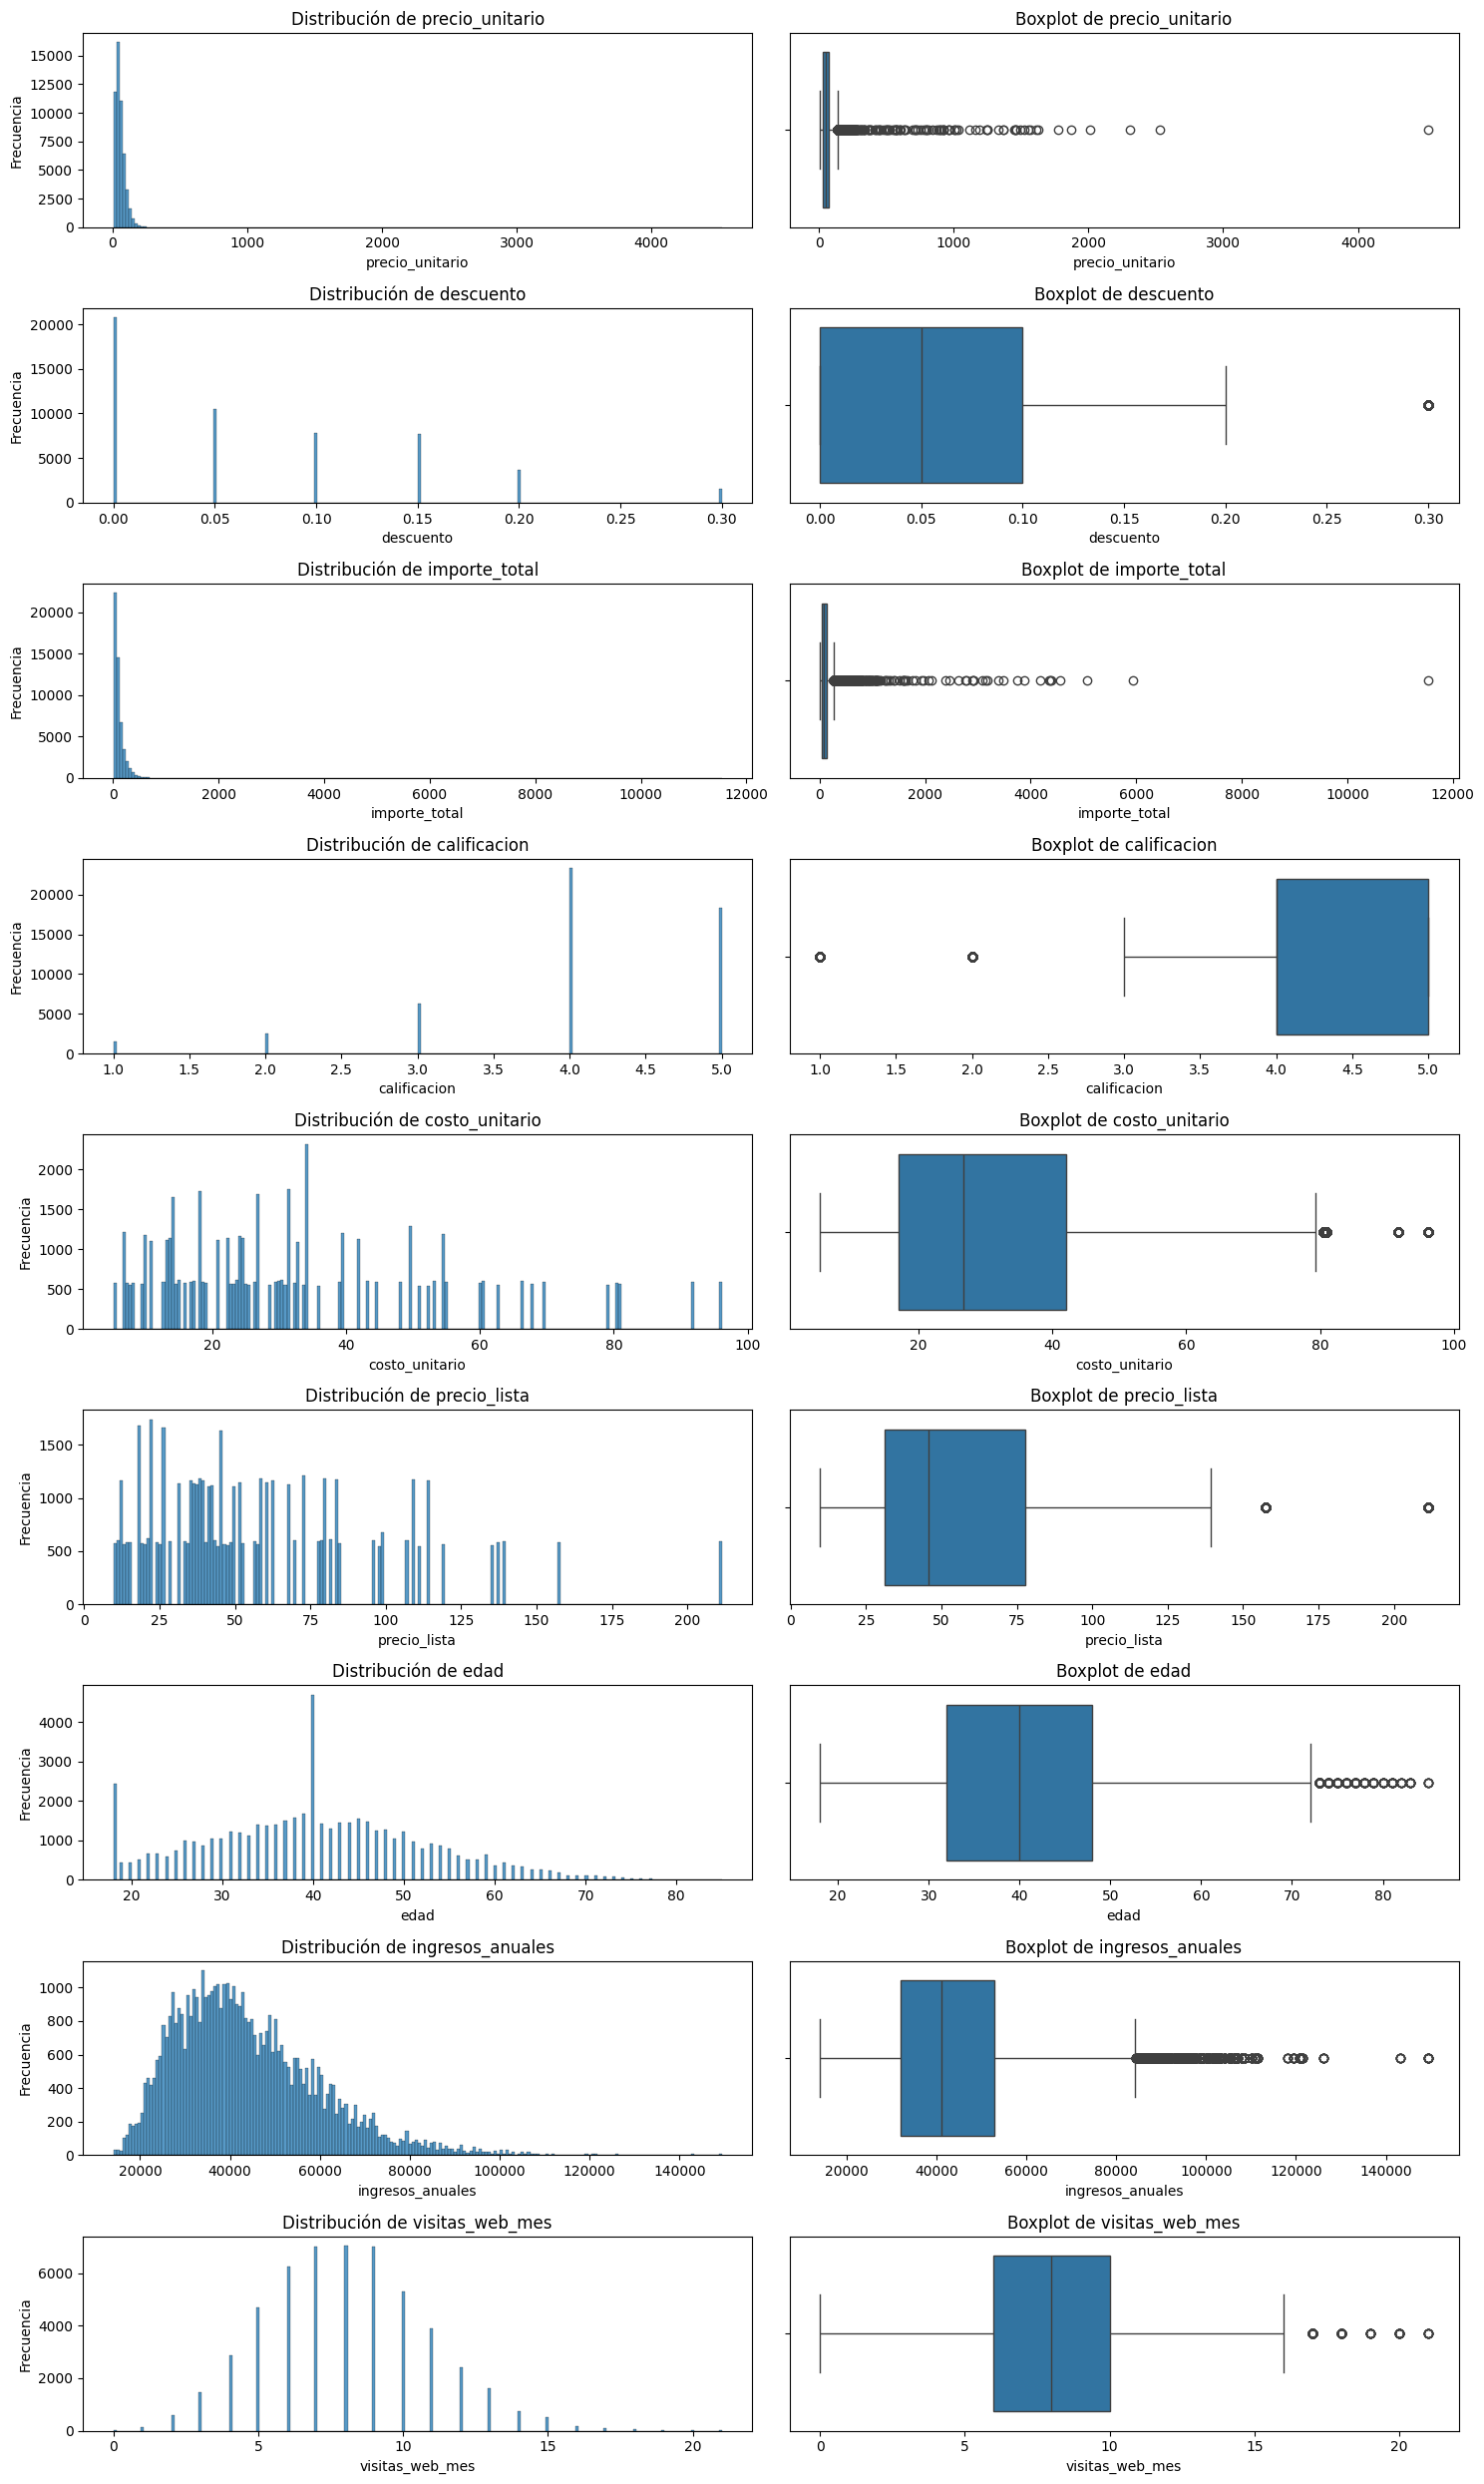

In [60]:
detectar_y_graficar_outliers(df)

In [61]:
# Crear columnas winsorizadas en paralelo, sin tocar las originales
for columna in ["precio_unitario", "importe_total"]:
    limite_99 = df[columna].quantile(0.99)
    df[f"{columna}_wz"] = df[columna].clip(upper=limite_99)
    n_afectados = (df[columna] > limite_99).sum()
    print(f"{columna}: {n_afectados} valores recortados al p99 ({limite_99:.2f}) en {columna}_wz")

precio_unitario: 520 valores recortados al p99 (177.66) en precio_unitario_wz
importe_total: 520 valores recortados al p99 (503.06) en importe_total_wz


In [62]:
df.columns 

Index(['order_id', 'id_cliente', 'product_id', 'fecha_pedido', 'cantidad',
       'precio_unitario', 'descuento', 'importe_total', 'metodo_pago',
       'envio_gratis', 'calificacion', 'devuelto', 'canal', 'año_ventas',
       'categoria_producto', 'nombre_producto', 'marca', 'costo_unitario',
       'precio_lista', 'peso_kg', 'proveedor', 'stock_disponible',
       'fecha_lanzamiento', 'rating_promedio_producto', 'edad', 'estado_civil',
       'nivel_educativo', 'ingresos_anuales', 'tiene_hijos',
       'adolescentes_en_casa', 'fecha_registro', 'ciudad', 'region',
       'latitude', 'longitude', 'segmento_cliente', 'visitas_web_mes',
       'precio_unitario_wz', 'importe_total_wz'],
      dtype='str')

In [63]:
comparacion = pd.DataFrame({
    "original_mean": df[["precio_unitario", "importe_total"]].mean(),
    "wz_mean": df[["precio_unitario_wz", "importe_total_wz"]].mean().values,
    "original_std": df[["precio_unitario", "importe_total"]].std(),
    "wz_std": df[["precio_unitario_wz", "importe_total_wz"]].std().values,
})
print(comparacion.round(3))

                 original_mean  wz_mean  original_std  wz_std
precio_unitario         56.445   54.938        56.315  34.597
importe_total          107.285  104.165       137.828  95.153


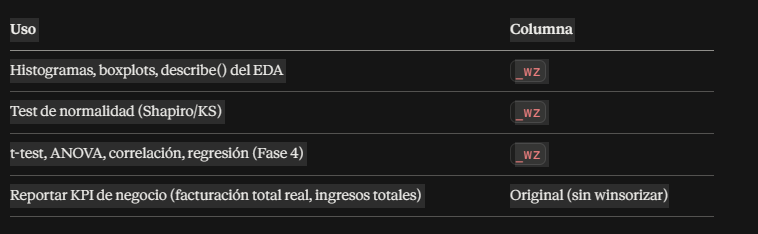

**Observaciones**
- Tras revisar las columnas con outliers no se realiza ningún tipo de cambio sobres estas salvo las columnas `'precio_unitario', 'importe_total'` que se ha decidido crear dos columnas nuevas  `'precio_unitario_wz', 'importe_total_wz'` aplicandole la winsorización, el motivo es que se usará la versión winsorizada (_wz) para EDA visual y pruebas estadísticas; la original se conservará para reportar cifras de negocio.


### 8️⃣ Guardar el dataset limpio
Guardamos el resultado de esta fase como `02_datos_limpios` para poder continuar con la Fase 3 (EDA,análisis descriptio y visualizaciones) sin tener que repetir la carga y el merge cada vez.


In [64]:
df.to_csv(r"../data/processed/02_datos_limpios.csv", index=False)
print(f"Guardado: {df.shape[0]} filas x {df.shape[1]} columnas")

Guardado: 52000 filas x 39 columnas
